In [ ]:
'''Problem statement and Objective:
Objective:
To build a machine learning pipeline that predicts whether a customer will churn (leave) or not using historical customer data.

Problem Statement:
Customer churn is a major issue in telecom companies where customers leave the service. Predicting churn helps companies take preventive actions.


In [ ]:
# Install required libraries
!pip install pandas scikit-learn joblib

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [16]:
import pandas as pd

# Load dataset directly from GitHub (IBM Telco Churn dataset)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

# Display first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# Data Preprocessing

# Drop unnecessary column
df = df.drop("customerID", axis=1)

# Convert TotalCharges to numeric (it may contain blanks)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Remove missing values
df = df.dropna()

# Separate features and target
X = df.drop("Churn", axis=1)

# Convert target to numeric (Yes=1, No=0)
y = df["Churn"].map({"Yes": 1, "No": 0})

print("Data cleaned successfully")

Data cleaned successfully


In [18]:
# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Categorical Columns: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [19]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),                # Scale numerical features
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)  # Encode categorical features
])

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Combine preprocessing + model into one pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [21]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split done")

Data split done


In [22]:
# Create pipeline using Logistic Regression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7874911158493249


In [23]:
#Hyperparameter Tuning (GridSearchCV)

from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [5, 10, None]
}

# Apply GridSearch
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

# Train model
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 50}


In [24]:
# Model evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = grid.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Detailed report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7924662402274343

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.65      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
 [[933 100]
 [192 182]]


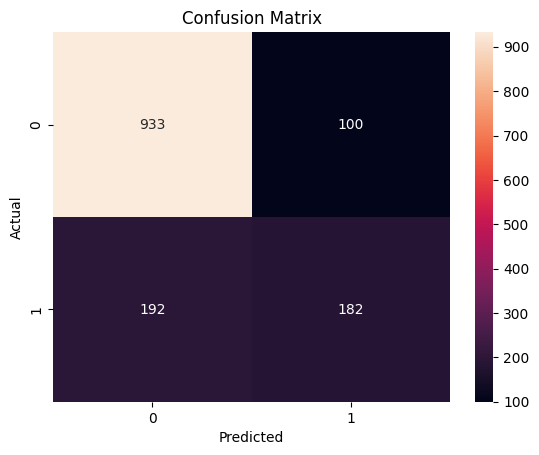

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
# Compare model performance

rf_pred = grid.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.7874911158493249
Random Forest Accuracy: 0.7924662402274343


In [26]:
# save model
import joblib

# Save trained pipeline
joblib.dump(grid.best_estimator_, "churn_pipeline.pkl")

print("Model saved successfully ")

Model saved successfully 


In [ ]:
# Final Summary and Insights

## Project Summary
An end-to-end machine learning pipeline was developed to predict customer churn using the IBM Telco Customer Churn dataset.

## Models Used
- Logistic Regression
- Random Forest

## Techniques Applied
- Data preprocessing
- One-Hot Encoding
- Feature Scaling
- Pipeline API
- GridSearchCV Hyperparameter Tuning

## Evaluation
Models were evaluated using:
- Accuracy
- Classification Report
- Confusion Matrix

## Conclusion
The pipeline successfully automates preprocessing and prediction, making it suitable for deployment and future retraining.